# Mg-MOF-74 / CO2 Binding Energy Pipeline

Computes static CO2 binding energies across all Mg open-metal sites in Mg-MOF-74
using the UMA-S MLIP via FairChem. Results are saved to a timestamped JSON file.


In [1]:
# Install FairChem (run once per environment)
!uv pip install fairchem-core


Using Python 3.13.11 environment at: /Users/christopherli/miniconda3/envs/cms
Audited 1 package in 63ms


In [2]:
# Verify Hugging Face token has gated-repo read access.
# Required permissions in HF token settings:
#   * Read access to contents of all public gated repos you can access
#   * Read access to contents of all private gated repos you can access
from huggingface_hub import whoami
print(whoami())


{'type': 'user', 'id': '69d68ea13c3376473bce2de0', 'name': 'cl6767', 'fullname': 'Christopher Li', 'isPro': False, 'avatarUrl': '/avatars/e3e198b7951f0d1e6e6f0a47dc0e1f79.svg', 'orgs': [{'type': 'org', 'id': '64374111a701a7e744c02b0e', 'name': 'princetonu', 'fullname': 'Princeton University', 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/68e396f2b5bb631e9b2fac9a/b3xXusq8Zz3ej8Z6fRTSZ.png'}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'UMA', 'role': 'fineGrained', 'createdAt': '2026-04-08T18:31:19.183Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '67098f31ee3ea12411d3f44e', 'type': 'model', 'name': 'facebook/OMAT24'}, 'permissions': ['repo.content.read']}, {'entity': {'_id': '67f5b60a8f60757d94e3c170', 'type': 'model', 'name': 'facebook/OMol25'}, 'permissions': ['repo.content.read']}, {'entity': {'_id': '67f5bb06b8e3712b3da49bfc', 'type': 'model', 'name': 'facebook/UMA'}, 'permissions': ['repo.con

In [3]:
# ── Model & Calculator ──────────────────────────────────────────────────────
# Load the UMA-S-1P1 MLIP and wrap it in an ASE-compatible calculator.
# task_name='omat' targets the Open Materials dataset potential.
from fairchem.core import pretrained_mlip, FAIRChemCalculator

predictor = pretrained_mlip.get_predict_unit(
    model_name='uma-s-1p1',
    device='cpu'
)
calc = FAIRChemCalculator(predictor, task_name='omat')


W0417 13:11:23.680000 91207 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Warp DeprecationWarning: The symbol `warp.vec` will soon be removed from the public API. Use `warp.types.vector` instead.


In [4]:
# ── Sanity Check ────────────────────────────────────────────────────────────
# Quick smoke-test: compute energy of bulk Si to confirm the calculator works.
from ase.build import bulk

atoms = bulk('Si')
atoms.calc = calc
e = atoms.get_potential_energy()
print(f'Si bulk energy: {e:.4f} eV  (expected ~negative value)')


Si bulk energy: -10.8231 eV  (expected ~negative value)


In [5]:
# ── Load Structures & Geometry Relaxation ───────────────────────────────────
# Read Mg-MOF-74 from CIF and build a free CO2 molecule.
# Both are relaxed with BFGS (fmax=0.01 eV/A) to obtain reference energies
# E_mof and E_co2 used throughout for binding-energy calculations.
#
# NOTE: co2.center(vacuum=10.0) prevents spurious periodic interactions
#       for the isolated molecule.
from ase.io import read
from ase.build import molecule
from ase.optimize import BFGS

mof_74 = read('mg_mof74.cif')
co2    = molecule('CO2')

mof_74.calc = calc
co2.calc    = calc

# Relax MOF
opt_mof = BFGS(mof_74, logfile='opt_mof_74.log')
opt_mof.run(fmax=0.01)
E_mof = mof_74.get_potential_energy()
print(f'E(Mg-MOF-74) = {E_mof:.6f} eV')

# Relax free CO2 in a vacuum box
co2.center(vacuum=10.0)
opt_co2 = BFGS(co2, logfile='opt_co2.log')
opt_co2.run(fmax=0.01)
E_co2 = co2.get_potential_energy()
print(f'E(CO2, free) = {E_co2:.6f} eV')


E(Mg-MOF-74) = -1177.415314 eV
E(CO2, free) = -22.596883 eV


In [6]:
# ── CO2 Placement Helper Functions ──────────────────────────────────────────
import numpy as np
from ase.geometry import get_distances

def is_valid_position_full(mof, co2, cutoff=1.6):
    """Return True if the minimum MOF-CO2 atom distance exceeds the cutoff (A)."""
    dmat = get_distances(
        mof.positions, co2.positions,
        cell=mof.get_cell(), pbc=mof.get_pbc()
    )[1]
    return np.min(dmat) > cutoff

def get_directions():
    """Return unit vectors along +/-x, +/-y, +/-z as CO2 approach directions."""
    dirs = [[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]]
    return [np.array(d) / np.linalg.norm(d) for d in dirs]

def place_co2_oriented(mof, co2, metal_index):
    """Place CO2 near a Mg site without atomic overlap.

    Tries each of the +/-x/y/z approach directions and Mg-O distances in
    2.2-2.8 A. Returns the first valid (co2_copy, metadata) tuple,
    or (None, None) if all placements clash.
    """
    metal_pos  = mof.positions[metal_index]
    for direction in get_directions():
        for d_mg_o in np.linspace(2.2, 2.8, 7):
            co2_copy = co2.copy()
            # Align CO2 molecular axis with the approach direction
            co2_axis = co2_copy.positions[2] - co2_copy.positions[0]
            co2_axis /= np.linalg.norm(co2_axis)
            v     = np.cross(co2_axis, direction)
            angle = np.degrees(np.arccos(np.clip(np.dot(co2_axis, direction), -1, 1)))
            if np.linalg.norm(v) > 1e-8:
                co2_copy.rotate(angle, v, center='COM')
            # Translate so the proximal O sits at d_mg_o from the metal
            co2_copy.positions += (metal_pos + d_mg_o * direction) - co2_copy.positions[0]
            if is_valid_position_full(mof, co2_copy):
                return co2_copy, {'metal_index': metal_index,
                                   'direction': direction, 'mg_o_distance': d_mg_o}
    return None, None

def compute_binding_energy(mof, co2_placed):
    """Relax MOF+CO2 and return E_bind = E(system) - E(MOF) - E(CO2) in eV."""
    system = mof.copy()
    system += co2_placed
    system.calc = calc
    BFGS(system, logfile=None).run(fmax=0.05)
    return system.get_potential_energy() - E_mof - E_co2


In [7]:
# ── Single-Site Test (Mg index 14) ──────────────────────────────────────────
# Validation before the full loop: place CO2 at one known Mg site,
# relax the combined system, and inspect Mg-O distances before and after.
from ase.io import write

mg_idx = 14
print(f'Testing Mg site index: {mg_idx}, symbol = {mof_74[mg_idx].symbol}')
if mof_74[mg_idx].symbol != 'Mg':
    raise ValueError(f'Atom {mg_idx} is {mof_74[mg_idx].symbol}, not Mg.')

co2_placed, metadata = place_co2_oriented(mof_74, co2, mg_idx)
if co2_placed is None:
    raise RuntimeError('Could not place CO2 near Mg without overlap.')
print('CO2 placed successfully -- metadata:', metadata)

system = mof_74.copy()
system += co2_placed
system.calc = calc

print('\nInitial Mg-O distances:')
for j in range(len(mof_74), len(system)):
    if system[j].symbol == 'O':
        print(f'  O atom {j}: {system.get_distance(mg_idx, j, mic=True):.3f} A')

opt_system = BFGS(system, logfile='opt_single_site.log')
opt_system.run(fmax=0.05)

E_total      = system.get_potential_energy()
E_bind_test  = E_total - E_mof - E_co2
print(f'\nE(total) = {E_total:.6f} eV')
print(f'E(bind)  = {E_bind_test:.6f} eV')

print('\nFinal Mg-O distances:')
co2_start = len(mof_74)
for j in range(co2_start, len(system)):
    if system[j].symbol == 'O':
        print(f'  O atom {j}: {system.get_distance(mg_idx, j, mic=True):.3f} A')


Testing Mg site index: 14, symbol = Mg
CO2 placed successfully -- metadata: {'metal_index': 14, 'direction': array([0., 1., 0.]), 'mg_o_distance': np.float64(2.8)}

Initial Mg-O distances:
  O atom 163: 1.620 A
  O atom 164: 3.980 A

E(total) = -1200.529892 eV
E(bind)  = -0.517695 eV

Final Mg-O distances:
  O atom 163: 2.367 A
  O atom 164: 4.390 A


In [8]:
# ── Binding Energy Loop: All Mg Sites ───────────────────────────────────────
# Iterates over every Mg atom, places CO2, relaxes the combined system, and
# records binding energy + Mg-O distance. Results stored in `results` list.
import numpy as np

metal_indices = [i for i, a in enumerate(mof_74) if a.symbol == 'Mg']
test_sites    = metal_indices
print(f'Testing {len(test_sites)} Mg sites: {test_sites}')

results = []

for idx in test_sites:
    co2_placed, meta = place_co2_oriented(mof_74, co2, idx)
    if co2_placed is None:
        print(f'Site {idx}: placement failed -- skipping')
        continue

    print(f'\nSite {idx} | dir: {meta["direction"]} | Mg-O start: {meta["mg_o_distance"]:.2f} A')

    system = mof_74.copy()
    system += co2_placed
    system.calc = calc

    co2_start  = len(mof_74)
    start_dist = system.get_distance(idx, co2_start, mic=True)

    BFGS(system, logfile=None).run(fmax=0.05)

    # Find the O in CO2 closest to Mg after relaxation (molecule may have flipped)
    o_distances = {j: system.get_distance(idx, j, mic=True)
                   for j in range(co2_start, len(system)) if system[j].symbol == 'O'}
    closest_o      = min(o_distances, key=o_distances.get)
    final_mg_o     = o_distances[closest_o]
    for j, d in o_distances.items():
        print(f'  O atom {j}: Mg-O = {d:.3f} A')

    E_total = system.get_potential_energy()
    E_bind  = E_total - E_mof - E_co2
    print(f'  Final Mg-O (closest O, atom {closest_o}): {final_mg_o:.3f} A')
    print(f'  E_bind = {E_bind:.4f} eV')

    results.append({'site': idx, 'E_bind': E_bind, 'direction': meta['direction'],
                    'distance': meta['mg_o_distance'], 'start_dist': start_dist,
                    'final_mg_o_dist': final_mg_o})


Testing 18 Mg sites: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Site 0 | dir: [-1.  0.  0.] | Mg-O start: 2.80 A
  O atom 163: Mg-O = 2.346 A
  O atom 164: Mg-O = 4.389 A
  Final Mg-O (closest O, atom 163): 2.346 A
  E_bind = -0.5518 eV

Site 1 | dir: [ 0. -1.  0.] | Mg-O start: 2.80 A
  O atom 163: Mg-O = 2.343 A
  O atom 164: Mg-O = 4.190 A
  Final Mg-O (closest O, atom 163): 2.343 A
  E_bind = -0.5670 eV

Site 2 | dir: [0. 1. 0.] | Mg-O start: 2.80 A
  O atom 163: Mg-O = 2.367 A
  O atom 164: Mg-O = 4.390 A
  Final Mg-O (closest O, atom 163): 2.367 A
  E_bind = -0.5177 eV

Site 3 | dir: [1. 0. 0.] | Mg-O start: 2.80 A
  O atom 163: Mg-O = 2.340 A
  O atom 164: Mg-O = 4.384 A
  Final Mg-O (closest O, atom 163): 2.340 A
  E_bind = -0.5620 eV

Site 4 | dir: [0. 1. 0.] | Mg-O start: 2.80 A
  O atom 163: Mg-O = 2.341 A
  O atom 164: Mg-O = 4.204 A
  Final Mg-O (closest O, atom 163): 2.341 A
  E_bind = -0.5705 eV

Site 5 | dir: [ 0. -1.  0.] | Mg-O start: 2.80 A
  O a

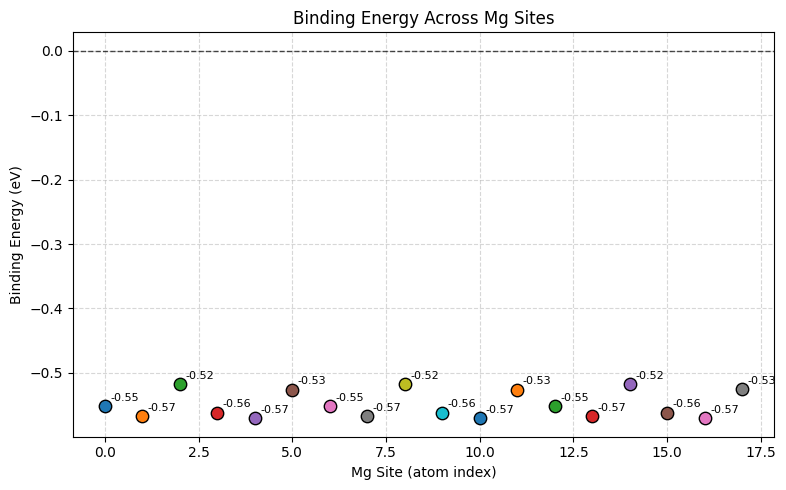

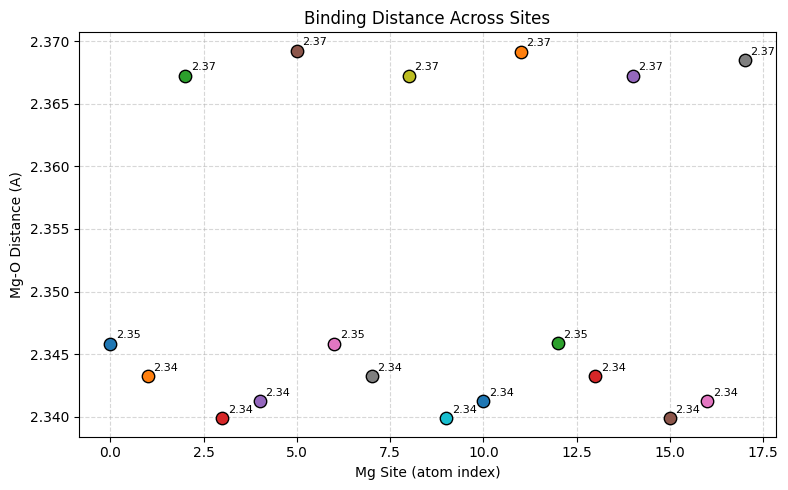

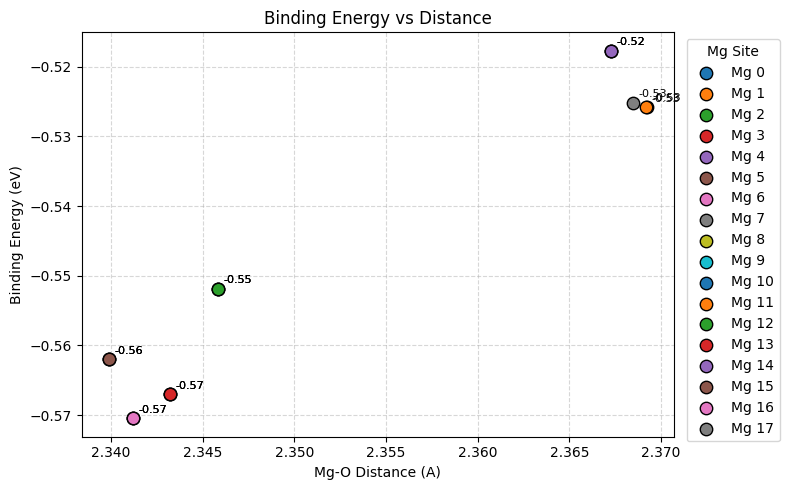

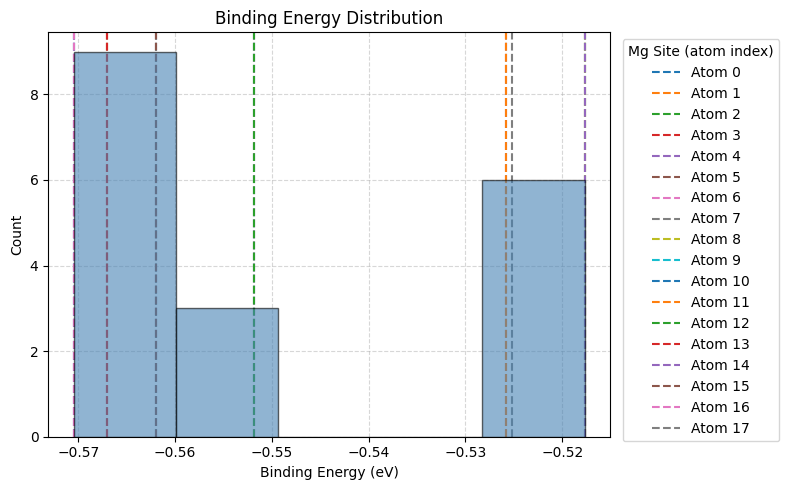

In [9]:
# ── Plot Results ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from datetime import datetime

sites   = [r['site']            for r in results]
E_binds = [r['E_bind']          for r in results]
dists   = [r['final_mg_o_dist'] for r in results]
colors  = plt.cm.tab10.colors
ts      = datetime.now().strftime('%Y%m%d_%H%M%S')

# Binding energy vs site index
fig, ax = plt.subplots(figsize=(8, 5))
for i, (s, e) in enumerate(zip(sites, E_binds)):
    ax.scatter(s, e, color=colors[i%10], edgecolors='black', s=80, zorder=3)
    ax.annotate(f'{e:.2f}', xy=(s,e), xytext=(4,4), textcoords='offset points', fontsize=8)
ax.axhline(0, color='black', ls='--', lw=1, alpha=0.7)
ax.set(xlabel='Mg Site (atom index)', ylabel='Binding Energy (eV)', title='Binding Energy Across Mg Sites')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'binding_energy_across_sites_{ts}.png', dpi=150, bbox_inches='tight')
plt.show()

# Mg-O distance vs site index
fig, ax = plt.subplots(figsize=(8, 5))
for i, (s, d) in enumerate(zip(sites, dists)):
    ax.scatter(s, d, color=colors[i%10], edgecolors='black', s=80, zorder=3)
    ax.annotate(f'{d:.2f}', xy=(s,d), xytext=(4,4), textcoords='offset points', fontsize=8)
ax.set(xlabel='Mg Site (atom index)', ylabel='Mg-O Distance (A)', title='Binding Distance Across Sites')
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'binding_distance_across_sites_{ts}.png', dpi=150, bbox_inches='tight')
plt.show()

# Binding energy vs Mg-O distance
fig, ax = plt.subplots(figsize=(8, 5))
for i, (s, d, e) in enumerate(zip(sites, dists, E_binds)):
    ax.scatter(d, e, color=colors[i%10], edgecolors='black', s=80, zorder=3, label=f'Mg {s}')
    ax.annotate(f'{e:.2f}', xy=(d,e), xytext=(4,4), textcoords='offset points', fontsize=8)
ax.set(xlabel='Mg-O Distance (A)', ylabel='Binding Energy (eV)', title='Binding Energy vs Distance')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(title='Mg Site', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig(f'binding_energy_vs_distance_{ts}.png', dpi=150, bbox_inches='tight')
plt.show()

# Binding energy distribution histogram
fig, ax = plt.subplots(figsize=(8, 5))
for i, (s, e) in enumerate(zip(sites, E_binds)):
    ax.axvline(e, color=colors[i%10], ls='--', lw=1.5, label=f'Atom {s}')
ax.hist(E_binds, bins=5, color='steelblue', edgecolor='black', alpha=0.6, zorder=2)
ax.set(xlabel='Binding Energy (eV)', ylabel='Count', title='Binding Energy Distribution')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(title='Mg Site (atom index)', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig(f'binding_energy_distribution_{ts}.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Summary & Save ──────────────────────────────────────────────────────────
# Print the 3 lowest-binding-energy (strongest adsorption) sites,
# then save full results to a timestamped JSON file.
import json
from datetime import datetime

print('Top 3 strongest binding sites:')
for r in sorted(results, key=lambda x: x['E_bind'])[:3]:
    print(f"  Site {r['site']}: E_bind = {r['E_bind']:.3f} eV, "
          f"Mg-O = {r['final_mg_o_dist']:.2f} A, direction = {r['direction']}")

# Serialize numpy arrays before JSON dump
for r in results:
    r['direction'] = r['direction'].tolist()

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'results_{ts}.txt'
with open(filename, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved to {filename}')
